# 公式LLM-X dataset: raw scan / token inspection

現在のrawファイルをread-onlyで検査し、raw → preprocessing → prompt → local tokenizerを確認します。
このNotebook単独で上から実行できます。もう一方のデータ調査は [02_external_data_and_token_inspection.ipynb](02_external_data_and_token_inspection.ipynb) に分離しています。
data/の変更・ダウンロード・モデル推論・API呼び出しは行いません。結果はメモリ上に保持します。

全体scan → 一覧 → 保存inventoryとの任意比較 → 選択record → 対象範囲のtoken計測・比較の順です。


## 1. imports / path

scan対象directory、実ファイルのschemaを取得する関数、reader、preprocessing、token counterを明示します。


In [24]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "dataset_adapters").is_dir() and (p / "configs/sources.json").is_file()), None)
if ROOT is None:
    raise RuntimeError("workspace直下またはnotebooks/から起動してください。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tools.inventory_llmx_data import create_inventory
from dataset_adapters.base import inventory_context
from dataset_adapters.registry import get_adapter
from tools.live_inspection import (
    official_frames, compare_frames, show_frame,
    token_summary_frame, compare_saved_tokens,
)
from tools.notebook_inspection import (
    select_record, preview_raw, preprocessing_for_inspection,
    selected_query, token_record, read_batch_summary,
)
from tools.count_input_tokens import resolve_encoding
from tools.token_inventory import build_token_inventory

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)
print("Official raw:", ROOT / "data/llmx_data")
print("No API clients. Scan/token results stay in memory; saved inventories are not overwritten.")


Official raw: /Users/cls-lab/Git/Matsuo/mental-modeling-openai/data/llmx_data
No API clients. Scan/token results stay in memory; saved inventories are not overwritten.


## 2. LIVE SCAN: official raw

create_inventory()がoffline_data以下の全episode NPZをallow_pickle=Falseで読みます。
checkpoint等の非episodeファイルはmetadataのみ。shapeは実配列どおりで、singleton次元を削除しません。


In [25]:
llmx_inventory = create_inventory(ROOT / "data/llmx_data")
print("LIVE:", llmx_inventory["task_count"], "tasks,",
      llmx_inventory["episode_count"], "episodes,",
      llmx_inventory["total_timesteps"], "timesteps")


LIVE: 20 tasks, 172 episodes, 15200 timesteps


## 3. official task overview

以下の3 DataFrameは、上で作ったllmx_inventory objectのみから整形します。

### official_tasks_df：カラムの意味

1行は1タスクの集計です。全公式タスクを対象とし、この表で統計を再計算せずcreate_inventory()の結果を取り出します。

| カラム | 意味・計算方法 |
| --- | --- |
| `task` | タスク名。例：`MountainCar-v0`。 |
| `number_of_episodes` | そのタスクのエピソードNPZファイル数。`len(files)`。1ファイルを1エピソードとして数える。 |
| `total_timesteps` | 各NPZの`states.shape[0]`を合計したステップ数。秒数ではない。長さが取得できないファイルは合計から除外する。 |
| `timesteps_min` | エピソード長（`states.shape[0]`）の最小値。 |
| `timesteps_max` | エピソード長の最大値。 |
| `timesteps_mean` | エピソード長の算術平均。長さが取得できたファイルが対象。 |
| `state_dimensions` | 各`states`配列の第0軸以外の長さの積を取り、重複を除いて並べたリスト。`[200, 4]`なら4。 |
| `action_dimensions` | 各`actions`配列の第0軸以外の長さの積を取り、重複を除いて並べたリスト。 |
| `action_kind` | ファイルごとの判定結果の種類一覧。actionを1ステップ1要素に並べられ、全値が有限かつ整数相当なら`discrete`、それ以外は`continuous`。環境の正式なaction space定義ではなく、値からの判定。 |
| `npz_keys` | そのタスクのNPZに存在するキー名の和集合。全ファイルに全キーがあるという意味ではない。 |
| `schema_consistent_except_T` | 時系列配列の第0軸を`T`に置き換えたschemaが全ファイルで同じか。キー・dtype・残りのshapeを比較し、`episodic_return`のshapeは置き換えない。 |


In [26]:
official_tasks_df, official_files_df, official_arrays_df = official_frames(llmx_inventory)
show_frame(official_tasks_df, title="LIVE official_tasks_df — 1 task / row")


,task,number_of_episodes,total_timesteps,timesteps_min,timesteps_max,timesteps_mean,state_dimensions,action_dimensions,action_kind,npz_keys,schema_consistent_except_T
0,MiniGrid-DoorKey-5x5-v0,24,226,7,13,9.416667,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
1,MiniGrid-Empty-Random-5x5-v0,11,30,1,6,2.727273,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
2,MiniGrid-Fetch-5x5-N2-v0,17,210,1,125,12.352941,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
3,MiniGrid-GoToDoor-5x5-v0,5,307,3,100,61.400000,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
4,MiniGrid-KeyCorridorS3R1-v0,11,162,14,15,14.727273,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
5,MiniGrid-Unlock-v0,10,130,9,22,13.000000,[147],[1],[discrete],"[actions, agent_dirs, dir_vectors, episodic_return, rewards, states]",True
6,HalfCheetah-v4,3,3000,1000,1000,1000.000000,[17],[6],[continuous],"[actions, episodic_return, rewards, states]",True
7,Pusher-v4,6,600,100,100,100.000000,[23],[7],[continuous],"[actions, episodic_return, rewards, states]",True
8,Reacher-v4,5,250,50,50,50.000000,[11],[2],[continuous],"[actions, episodic_return, rewards, states]",True
9,Acrobot-v1,5,399,69,90,79.800000,[6],[1],[discrete],"[actions, episodic_return, rewards, states]",True


## 4. official全episode / array shape

official_files_dfは1 episode/file=1行、official_arrays_dfは1 file×1 NPZ key=1行です。
**全行を省略せずスクロール表示**します。任意の絞り込みもDataFrame.query()で可能です。

### official_files_df：カラムの意味

1行は1つのエピソードNPZファイルです。全公式タスクのファイルをまとめています。

| カラム | 意味・計算方法 |
| --- | --- |
| `task` | ファイルが属するタスク名。 |
| `episode_id` | タスク内のファイルを`relative_path`の文字列順に並べて0から振った番号。タスクごとに0へ戻る。ファイル名から取り出した数字ではない。 |
| `filename` | NPZのファイル名。例：`episode_0.npz`。 |
| `relative_path` | inventory作成時のデータルート（既定：`data/llmx_data`）からNPZまでの相対パス。 |
| `timesteps` | そのNPZの`states.shape[0]`。stateがない場合や0次元の場合は未取得（None/NaN）。 |
| `size_bytes` | ディスク上のNPZファイル自体のサイズ（バイト）。展開後の配列の容量ではない。 |
| `schema_group` | 正規化したschemaのSHA256先頭16桁。同じIDなら同じschemaグループ。時系列長を`T`として比較するため、長さが違っても同じIDになり得る。raw配列は変更しない。 |

### official_arrays_df：カラムの意味

1行は1つのNPZ内の1配列です。例えばNPZに4つの配列キーがあれば、そのファイルについて4行できます。配列の実値ではなく検査結果を表示します。

| カラム | 意味・計算方法 |
| --- | --- |
| `task` | 配列を含むNPZが属するタスク名。 |
| `episode_id` | `official_files_df`と同じ、タスク内の相対パス順の0-based番号。単独では全タスクを通した一意IDではない。 |
| `filename` | 配列を含むNPZのファイル名。 |
| `relative_path` | データルートからNPZまでの相対パス。`key`と組み合わせて配列を特定する。 |
| `key` | NPZ内の配列名。例：`states`、`actions`、`rewards`、`episodic_return`。 |
| `shape` | 実配列の各軸の長さ。例：`[200, 4]`。長さ1の軸も省略しない。スカラーは`[]`。 |
| `dtype` | 配列の要素のデータ型。例：`float64`、`int64`。 |
| `ndim` | 配列の軸数。`[200, 4]`なら2。stateの特徴量数とは異なる。スカラーは0。 |
| `num_elements` | 配列の全要素数（`array.size`）。`[200, 4]`なら800。バイト数ではない。スカラーは1。 |


In [27]:
show_frame(official_files_df, title="LIVE official_files_df — all episodes")
show_frame(official_arrays_df, title="LIVE official_arrays_df — all file × NPZ key rows")
# 例: official_arrays_df.query("task == 'MountainCar-v0' and key == 'states'")


,task,episode_id,filename,relative_path,timesteps,size_bytes,schema_group
0,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,11,3547,e1b19ffbe0661f64
1,MiniGrid-DoorKey-5x5-v0,1,episode_1_seed1.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed1.npz,7,2815,e1b19ffbe0661f64
2,MiniGrid-DoorKey-5x5-v0,2,episode_1_seed2.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed2.npz,13,3913,e1b19ffbe0661f64
3,MiniGrid-DoorKey-5x5-v0,3,episode_2_seed41.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_2_seed41.npz,11,3547,e1b19ffbe0661f64
4,MiniGrid-DoorKey-5x5-v0,4,episode_2_seed42.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_2_seed42.npz,7,2815,e1b19ffbe0661f64
5,MiniGrid-DoorKey-5x5-v0,5,episode_2_seed45.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_2_seed45.npz,8,2998,e1b19ffbe0661f64
6,MiniGrid-DoorKey-5x5-v0,6,episode_3_seed141.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_3_seed141.npz,11,3547,e1b19ffbe0661f64
7,MiniGrid-DoorKey-5x5-v0,7,episode_3_seed142.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_3_seed142.npz,8,2998,e1b19ffbe0661f64
8,MiniGrid-DoorKey-5x5-v0,8,episode_3_seed145.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_3_seed145.npz,11,3547,e1b19ffbe0661f64
9,MiniGrid-DoorKey-5x5-v0,9,episode_4_seed123.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_4_seed123.npz,12,3730,e1b19ffbe0661f64


,task,episode_id,filename,relative_path,key,shape,dtype,ndim,num_elements
0,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,actions,"[11, 1]",int64,2,11
1,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,agent_dirs,"[11, 1]",int64,2,11
2,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,dir_vectors,"[11, 2]",int64,2,22
3,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,episodic_return,[1],float64,1,1
4,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,rewards,"[11, 1]",float32,2,11
5,MiniGrid-DoorKey-5x5-v0,0,episode_0_seed0.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_0_seed0.npz,states,"[11, 7, 7, 3]",uint8,4,1617
6,MiniGrid-DoorKey-5x5-v0,1,episode_1_seed1.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed1.npz,actions,"[7, 1]",int64,2,7
7,MiniGrid-DoorKey-5x5-v0,1,episode_1_seed1.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed1.npz,agent_dirs,"[7, 1]",int64,2,7
8,MiniGrid-DoorKey-5x5-v0,1,episode_1_seed1.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed1.npz,dir_vectors,"[7, 2]",int64,2,14
9,MiniGrid-DoorKey-5x5-v0,1,episode_1_seed1.npz,offline_data/minigrid_data/raw_transitions/MiniGrid-DoorKey-5x5-v0/episodes/episode_1_seed1.npz,episodic_return,[1],float64,1,1


## 5. LIVE SCAN vs SAVED INVENTORY — secondary validation

ここで初めて保存済みinventoryを読みます。ファイルがない場合もlive inspectionは可能です。
全件のkeyでouter joinし、新規／削除／shape・dtype変更・件数差を隠しません。
一致しなくてもrawを変更したりcacheを上書きしたりしません。


In [28]:
saved_base = ROOT / "outputs/dataset_inventory"
raw_validation = {}
if (saved_base / "llmx_schema.json").is_file():
    saved_llmx = json.loads((saved_base / "llmx_schema.json").read_text())
    _, saved_official_files, saved_official_arrays = official_frames(saved_llmx)
    raw_validation["official_files"] = compare_frames(
        official_files_df, saved_official_files, ["task", "relative_path"], ["timesteps", "size_bytes", "schema_group"])
    raw_validation["official_arrays"] = compare_frames(
        official_arrays_df, saved_official_arrays, ["task", "relative_path", "key"], ["shape", "dtype", "ndim", "num_elements"])
    display(pd.DataFrame([{"comparison": name, "rows": len(table),
                          "matches": int(table.matches.sum()), "differences": int((~table.matches).sum())}
                         for name, table in raw_validation.items()]))
    for name, table in raw_validation.items():
        if not table.matches.all():
            show_frame(table.loc[~table.matches], title=name + " differences", page_size=30)
else:
    print("Saved inventory not found. LIVE scan results remain the primary source.")


,comparison,rows,matches,differences
0,official_files,172,172,0
1,official_arrays,904,904,0


## 6. drill-down selection

全体を見た後、ここでdatasetを選びます。番号は0-basedです。
選択を変更したら「selected raw record」から「selected query token」まで再実行してください。


In [29]:
DATASET = "MountainCar-v0"
EPISODE = 0
SEQUENCE_ID = None
ROW_ID = None
INDEX = 10

HISTORY_SIZE = 1
METRIC = None
QUESTION_NAME = None  # None/Noneでそのtaskの既存LLM-X既定質問。
MODEL = "gpt-4o"
PREPROCESSING_CONFIG = None


## 7. selected raw record — RAW DATA

readerには同じlive inventoryを渡します。保存済みcacheをprimary sourceへ戻しません。
source file、選択sequence、全raw fieldのshape/dtypeと実値を表示します。


In [30]:
if DATASET not in {t["task"] for t in llmx_inventory["tasks"]}:
    raise ValueError("このNotebookの対象外datasetです。もう一方のNotebookを使用してください。")
with inventory_context(llmx_inventory, {}):
    adapter = get_adapter(DATASET)
sequence, raw_record = select_record(adapter, episode=EPISODE, sequence_id=SEQUENCE_ID, row_id=ROW_ID, index=INDEX)
if sequence is None:
    print("NOT_ACQUIRED: raw inspection unavailable.")
else:
    print("RAW RECORD")
    print("Source:", sequence.source_file, "\nSequence:", sequence.sequence_id, sequence.key)
    print("Episode:", raw_record["episode_id"], "Row:", raw_record.get("row_id"), "Index:", raw_record["index"])
    print("SHA256:", raw_record["source_file_sha256"])
    raw_fields_df = pd.DataFrame([{"field": name, **spec} for name, spec in raw_record["fields"].items()])
    show_frame(raw_fields_df, title="Selected raw fields")
    print(json.dumps(raw_record["fields"], ensure_ascii=False, indent=2))
    raw_preview = preview_raw(adapter, sequence)
    if isinstance(raw_preview, dict):
        for key, value in raw_preview.items():
            print("\n", key, "(episode scope)" if key == "episodic_return" else "[:5]")
            print(value)
    else:
        display(raw_preview)


RAW RECORD
Source: data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_0.npz 
Sequence: 0 offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_0.npz
Episode: 0 Row: None Index: 10
SHA256: c91b3e277decddff587601790c381096c5bab98fc726af94dba76d924e0ffa5b


,field,value,dtype,shape
0,states,"[[-0.45723235607147217, 0.006099471356719732]]",float32,"[1, 2]"
1,actions,[1],int64,[1]
2,rewards,[-1.0],float64,[1]
3,episodic_return,[[-105.0]],float32,"[1, 1]"


{
  "states": {
    "value": [
      [
        -0.45723235607147217,
        0.006099471356719732
      ]
    ],
    "dtype": "float32",
    "shape": [
      1,
      2
    ]
  },
  "actions": {
    "value": [
      1
    ],
    "dtype": "int64",
    "shape": [
      1
    ]
  },
  "rewards": {
    "value": [
      -1.0
    ],
    "dtype": "float64",
    "shape": [
      1
    ]
  },
  "episodic_return": {
    "value": [
      [
        -105.0
      ]
    ],
    "dtype": "float32",
    "shape": [
      1,
      1
    ]
  }
}

 states [:5]
[[[-0.49763566  0.        ]]

 [[-0.4968302   0.00080547]]

 [[-0.49522528  0.00160493]]

 [[-0.4928329   0.00239238]]

 [[-0.48967093  0.00316196]]]

 actions [:5]
[[2]
 [2]
 [2]
 [2]
 [2]]

 rewards [:5]
[[-1.]
 [-1.]
 [-1.]
 [-1.]
 [-1.]]

 episodic_return (episode scope)
[[-105.]]


## 8. PREPROCESSING → HISTORY

RAWとMODEL INPUT AFTER PREPROCESSINGは別です。
公式は既存LLM-X関数のwrapperを使い、元promptの意味を変更しません。


evaluation.py のプロンプト構築部分に対応するのは、その後に呼ばれる build_prompt_queries() です。


Notebook
  preprocessing_for_inspection() → 設定を読む
  selected_query()
    → queries_for_sequence()
      → build_prompt_queries()  → 公式関数でプロンプトを作る

| 処理 | 公式 `evaluate_episode()` | 本project `build_prompt_queries()` |
|---|---|---|
| タスク・質問の解決 | `resolve_task()` / `resolve_question()` | 同じ関数 |
| system promptの構築 | `system_prompt()` | 同じ関数 |
| 対象index・履歴範囲の決定 | `_query_indices()` / `_history_range()` | 同じ関数 |
| 質問文の構築 | `render_question()` | 同じ関数 |
| user promptの構築 | `user_prompt()` | 同じ関数 |
| モデルへの問い合わせ | `backend.complete()` | **しない** |
| 応答の採点 | `_score_response()` | **しない** |
| 戻り値 | 評価結果 `EvaluationResult` | プロンプト情報 `PromptQuery` を順次生成 |

In [31]:
config, preprocessing_status = preprocessing_for_inspection(DATASET, PREPROCESSING_CONFIG)
print(preprocessing_status)
query = None
if config is not None and sequence is not None:
    display(config)
    try:
        query = selected_query(adapter, sequence, raw_record["index"], config, HISTORY_SIZE, METRIC, QUESTION_NAME)
    except (ValueError, IndexError) as exc:
        print("Model input: N/A —", exc)
    if query is not None:
        print("MODEL INPUT AFTER PREPROCESSING:", config["prompt_mode"])
        print("Metric / question:", query.metric, query.question_name)
        print("H:", query.history_size, "history [start,end):", query.history_start, query.history_end)
        print("\nHISTORY\n", query.history_text)
else:
    print("Token count: N/A")


Model-input preprocessing: defined


{'name': 'llmx_original',
 'prompt_mode': 'original_llmx',
 'implementation': 'upstream/LLM-Xavier',
 'indexed_history': True,
 'numeric_precision': 4,
 'fetch_drop_last_state_feature': True,
 'semantics': 'upstream Episode/history_text/render_question/system_prompt/user_prompt unchanged'}

MODEL INPUT AFTER PREPROCESSING: original_llmx
Metric / question: next-action next_action_prediction
H: 1 history [start,end): 8 10

HISTORY
 Step 8:
  state: [[-0.4699,  0.006 ]]
  action: [2]
  reward: [-1.]

Step 9:
  state: [[-0.4633,  0.0065]]
  action: [1]
  reward: [-1.]


## 9. actual prompt全文

同じpreprocessingが作ったSYSTEM PROMPTとUSER PROMPT。文字列を表示するだけで送信しません。


In [32]:
if query is not None:
    print("Prompt mode:", config["prompt_mode"], "Preprocessing:", config["name"])
    print("\nSYSTEM PROMPT\n")
    print(query.system_prompt)
    print("\nUSER PROMPT\n")
    print(query.user_prompt)
else:
    print("Prompt: N/A")


Prompt mode: original_llmx Preprocessing: llmx_original

SYSTEM PROMPT

Below is a description of the "MountainCar-v0" task.

Task description:

        The Mountain Car MDP is a deterministic MDP that consists of a car placed stochastically at the bottom of a sinusoidal valley, with the only possible actions being the accelerations that can be applied to the car in either direction. The goal of the MDP is to strategically accelerate the car to reach the goal state on top of the right hill.
        

Observation space:

        The observation is a ndarray with shape (2,) where the elements correspond to the following:
        position of the car along the x-axis (range from -1.2 to 0.6), velocity of the car (range from -0.07 to 0.07)
        

Action space:

        There are 3 discrete deterministic actions,
        0: Accelerate to the left
        1: Do not accelerate
        2: Accelerate to the right
        

Reward space:

        The goal is to reach the flag placed on top of 

## 10. selected query token

CLI共通count_queryを使用。contentは実文字列のlocal tokenize結果、API入力はcontent+9の既存概算でserver usageではありません。
history/questionはBPE境界のためuser_tokensに単純加算できません。fallback使用時は明示します。


In [33]:
selected_tokens = None
if query is not None:
    encoding, fallback = resolve_encoding(MODEL)
    selected_tokens = token_record(query, sequence, config, encoding, fallback, MODEL)
    print("Model:", MODEL, "Tokenizer:", encoding.name, "Fallback:", fallback)
    names = ["system_tokens", "history_tokens", "question_tokens", "user_tokens",
             "total_content_tokens", "estimated_api_input_tokens"]
    display(pd.DataFrame([{"component": k, "tokens": selected_tokens[k]} for k in names]))
else:
    print("Token count: N/A")


Model: gpt-4o Tokenizer: o200k_base Fallback: False


,component,tokens
0,system_tokens,407
1,history_tokens,65
2,question_tokens,144
3,user_tokens,229
4,total_content_tokens,636
5,estimated_api_input_tokens,645


| component | 意味 |
|---|---|
| `system_tokens` | タスク説明など、system promptのtoken数 |
| `history_tokens` | 履歴部分だけの参考値。すでにuserに含まれる |
| `question_tokens` | 質問部分だけの参考値。すでにuserに含まれる |
| `user_tokens` | 導入文・履歴・質問を含むuser prompt全文 |
| `total_content_tokens` | `system_tokens + user_tokens` |
| `estimated_api_input_tokens` | 本文合計に、メッセージ形式の概算9 tokensを追加 |

## 11. LIVE TOKEN COUNT: official tasks

build_token_inventory()をCLIと共有し、今回の実行でprompt文字列を作りlocal tokenizeします。選択recordとは独立です。
公式のみを対象に、対応taskの全valid queryを計測します。元prompt未対応taskは理由付きskipします。
結果はmemoryに保持し、保存済みbatchを上書きしません。


In [34]:
TOKEN_MODEL = "gpt-4o"
TOKEN_HISTORY_SIZES = [1]


In [35]:
with inventory_context(llmx_inventory, {}):
    result = build_token_inventory(
        datasets="all", history_sizes=TOKEN_HISTORY_SIZES, model=TOKEN_MODEL,
    )
print("LIVE count:", result.metadata["number_of_datasets"], "datasets,",
      result.metadata["number_of_queries"], "query/history/static rows")
print("Tokenizer:", result.metadata["tokenizer"], "Fallback:", result.metadata["fallback_encoding_used"])
token_scopes_df = pd.DataFrame(result.scopes)
token_skipped_df = pd.DataFrame(result.skipped)
show_frame(token_scopes_df, title="LIVE scopes — full selected scope vs deterministic sample")
show_frame(token_skipped_df, title="Skipped datasets and reasons")


Acrobot-v1 H=1: full_selected_scope, 389/389 queries
CartPole-v1 H=1: full_selected_scope, 2490/2490 queries
FetchPickAndPlace-v2 H=1: full_selected_scope, 480/480 queries
FetchPush-v2 H=1: full_selected_scope, 480/480 queries
FetchSlide-v2 H=1: full_selected_scope, 480/480 queries
InvertedDoublePendulum-v4 H=1: full_selected_scope, 518/518 queries
InvertedPendulum-v4 H=1: full_selected_scope, 1409/1409 queries
LunarLander-v2 H=1: full_selected_scope, 738/738 queries
MiniGrid-Unlock-v0 H=1: full_selected_scope, 110/110 queries
MountainCar-v0 H=1: full_selected_scope, 1021/1021 queries
Pendulum-v1 H=1: full_selected_scope, 1980/1980 queries
LIVE count: 11 datasets, 10095 query/history/static rows
Tokenizer: o200k_base Fallback: False


,dataset_id,prompt_mode,history_size,preprocessing_config_sha256,preprocessing_name,count_scope,eligible_query_pool,selected_source_units,dataset_reader_records,sample_size,seed,source_globs
0,Acrobot-v1,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,389,5,399,389,0,"[""official episodes""]"
1,CartPole-v1,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,2490,5,2500,2490,0,"[""official episodes""]"
2,FetchPickAndPlace-v2,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,480,10,500,480,0,"[""official episodes""]"
3,FetchPush-v2,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,480,10,500,480,0,"[""official episodes""]"
4,FetchSlide-v2,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,480,10,500,480,0,"[""official episodes""]"
5,InvertedDoublePendulum-v4,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,518,10,538,518,0,"[""official episodes""]"
6,InvertedPendulum-v4,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,1409,5,1419,1409,0,"[""official episodes""]"
7,LunarLander-v2,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,738,3,744,738,0,"[""official episodes""]"
8,MiniGrid-Unlock-v0,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,110,10,130,110,0,"[""official episodes""]"
9,MountainCar-v0,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,llmx_original,full_selected_scope,1021,10,1041,1021,0,"[""official episodes""]"


,dataset_id,reason
0,BipedalWalker-v3,task class/description absent from upstream registry; raw readable; no safe version alias
1,HalfCheetah-v4,task class/description absent from upstream registry; raw readable; no safe version alias
2,MiniGrid-DoorKey-5x5-v0,task class/description absent from upstream registry; raw readable; no safe version alias
3,MiniGrid-Empty-Random-5x5-v0,task class/description absent from upstream registry; raw readable; no safe version alias
4,MiniGrid-Fetch-5x5-N2-v0,task class/description absent from upstream registry; raw readable; no safe version alias
5,MiniGrid-GoToDoor-5x5-v0,task class/description absent from upstream registry; raw readable; no safe version alias
6,MiniGrid-KeyCorridorS3R1-v0,task class/description absent from upstream registry; raw readable; no safe version alias
7,Pusher-v4,task class/description absent from upstream registry; raw readable; no safe version alias
8,Reacher-v4,task class/description absent from upstream registry; raw readable; no safe version alias


## 12. all_token_queries_df

1 query / history window / static record=1行。全計測行をmemory上のDataFrameとして保持します。
画面はページ表示だけですが、all_token_queries_df.query(...)で全件を直接検索できます。
episode_id / sequence_id / row_idは非該当ならNAです。


In [36]:
all_token_queries_df = pd.DataFrame(result.queries)
for col in ["episode_id", "sequence_id", "row_id", "query_index"]:
    all_token_queries_df[col] = all_token_queries_df[col].astype("Int64")
QUERY_START = 0
query_columns = [
    "dataset_id", "source_file", "episode_id", "sequence_id", "row_id", "query_index",
    "history_size", "prompt_mode", "preprocessing_name", "preprocessing_config_sha256",
    "estimated_api_input_tokens", "system_tokens", "user_tokens", "history_tokens", "question_tokens",
    "count_scope", "eligible_query_pool", "sample_size", "seed",
]
show_frame(all_token_queries_df[query_columns], title="LIVE all_token_queries_df", start=QUERY_START, page_size=100)
# 例: all_token_queries_df.query("dataset_id == 'MountainCar-v0' and episode_id == 0")
token_by_sequence_df = pd.DataFrame(result.by_sequence)


,dataset_id,source_file,episode_id,sequence_id,row_id,query_index,history_size,prompt_mode,preprocessing_name,preprocessing_config_sha256,estimated_api_input_tokens,system_tokens,user_tokens,history_tokens,question_tokens,count_scope,eligible_query_pool,sample_size,seed
0,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,2,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,888,573,306,117,169,full_selected_scope,389,389,0
1,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,3,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,888,573,306,116,170,full_selected_scope,389,389,0
2,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,4,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,117,170,full_selected_scope,389,389,0
3,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,5,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,118,169,full_selected_scope,389,389,0
4,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,6,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,117,170,full_selected_scope,389,389,0
5,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,7,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,117,170,full_selected_scope,389,389,0
6,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,8,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,118,169,full_selected_scope,389,389,0
7,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,9,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,117,170,full_selected_scope,389,389,0
8,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,10,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,889,573,307,117,170,full_selected_scope,389,389,0
9,Acrobot-v1,data/llmx_data/offline_data/physics_data/raw_transitions/Acrobot-v1/episodes/episode_0_seed1.npz,0,0,<NA>,11,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,888,573,306,117,169,full_selected_scope,389,389,0


## 13. token_by_dataset_df

dataset / mode / H / 前処理設定ごとに分離します。異なるprompt semanticsやsample scopeを混ぜて合算しません。
stdは母標準偏差、p95はnearest-rank（既存CLIと共通）です。


In [37]:
token_by_dataset_df = token_summary_frame(result)
summary_columns = [
    "dataset_id", "prompt_mode", "preprocessing_name", "history_size", "count_scope",
    "eligible_query_pool", "sample_size", "seed", "counted_queries", "mean", "std",
    "min", "median", "p95", "max", "total",
]
show_frame(token_by_dataset_df[summary_columns], title="LIVE token_by_dataset_df")


,dataset_id,prompt_mode,preprocessing_name,history_size,count_scope,eligible_query_pool,sample_size,seed,counted_queries,mean,std,min,median,p95,max,total
0,Acrobot-v1,original_llmx,llmx_original,1,full_selected_scope,389,389,0,389,887.868895,3.258492,880,888.0,890,910,345381
1,CartPole-v1,original_llmx,llmx_original,1,full_selected_scope,2490,2490,0,2490,830.610040,2.619846,825,830.0,833,845,2068219
2,FetchPickAndPlace-v2,original_llmx,llmx_original,1,full_selected_scope,480,480,0,480,2725.454167,13.663287,2643,2728.0,2736,2749,1308218
3,FetchPush-v2,original_llmx,llmx_original,1,full_selected_scope,480,480,0,480,2707.306250,7.648527,2625,2708.0,2716,2721,1299507
4,FetchSlide-v2,original_llmx,llmx_original,1,full_selected_scope,480,480,0,480,2744.916667,11.545261,2663,2746.0,2753,2765,1317560
5,InvertedDoublePendulum-v4,original_llmx,llmx_original,1,full_selected_scope,518,518,0,518,1550.810811,7.982058,1542,1549.0,1556,1592,803320
6,InvertedPendulum-v4,original_llmx,llmx_original,1,full_selected_scope,1409,1409,0,1409,1036.408801,2.283419,1030,1036.0,1039,1059,1460300
7,LunarLander-v2,original_llmx,llmx_original,1,full_selected_scope,738,738,0,738,1102.720867,25.266077,1074,1093.0,1168,1179,813808
8,MiniGrid-Unlock-v0,original_llmx,llmx_original,1,full_selected_scope,110,110,0,110,2145.000000,0.000000,2145,2145.0,2145,2145,235950
9,MountainCar-v0,original_llmx,llmx_original,1,full_selected_scope,1021,1021,0,1021,643.369246,2.651076,637,643.0,646,652,656880


## 14. dataset間token distribution

prompt_modeごとに図を分け、各datasetのpreprocessing_name・H・全件/sampleをラベルに表示します。
boxplotのひげは1.5×IQR、点はその外側。幅や点の数から未計測poolの分布を推定しません。


/var/folders/9v/4_0508ps1r79hjh0f80nm8800000gp/T/ipykernel_62546/2244758009.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=False)


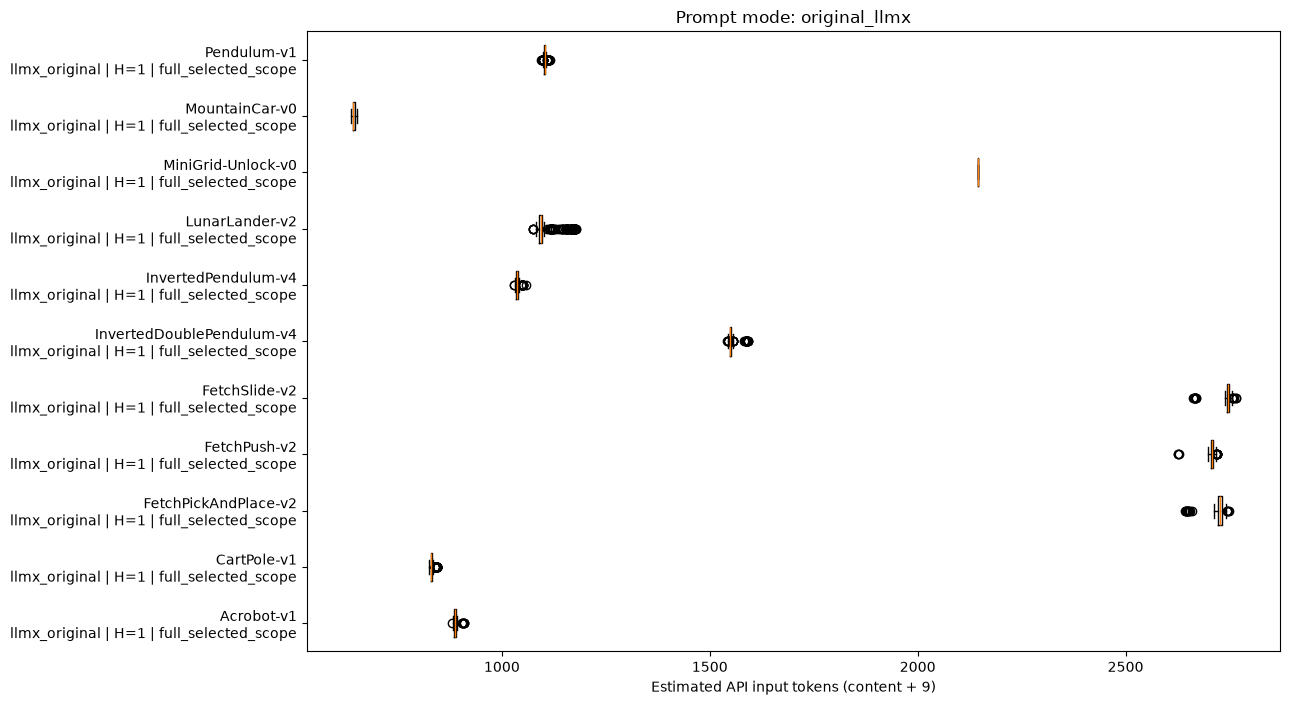

In [38]:
import matplotlib.pyplot as plt
for mode, mode_df in all_token_queries_df.groupby("prompt_mode", sort=True):
    grouped = list(mode_df.groupby(["dataset_id", "preprocessing_name", "history_size", "count_scope"], sort=True))
    labels = [f"{key[0]}\n{key[1]} | H={key[2]} | {key[3]}" for key, _ in grouped]
    values = [group["estimated_api_input_tokens"].to_numpy() for _, group in grouped]
    fig, ax = plt.subplots(figsize=(13, max(3, 0.65 * len(grouped))))
    ax.boxplot(values, vert=False)
    ax.set_yticks(range(1, len(labels) + 1), labels)
    ax.set_xlabel("Estimated API input tokens (content + 9)")
    ax.set_title(f"Prompt mode: {mode}")
    fig.tight_layout()
    plt.show()


## 15. largest/smallest token queries → raw/prompt drill-down

以下の行を見て「drill-down selection」の選択値を変更してください。
前処理設定・H・metric/questionも一致させ、raw表示から選択queryのtoken計測まで再実行すると同じpromptを確認できます。
各query行に実効設定JSONとSHA256を保持しています。


In [39]:
largest_token_queries_df = all_token_queries_df.nlargest(20, "estimated_api_input_tokens")
smallest_token_queries_df = all_token_queries_df.nsmallest(20, "estimated_api_input_tokens")
drill_columns = query_columns + ["metric", "question_name"]
show_frame(largest_token_queries_df[drill_columns], title="Largest 20 counted queries")
show_frame(smallest_token_queries_df[drill_columns], title="Smallest 20 counted queries")
example = largest_token_queries_df.iloc[0]
print("Example selection — copy into drill-down selection:")
print("DATASET =", repr(example["dataset_id"]))
print("EPISODE =", int(example["episode_id"]) if pd.notna(example["episode_id"]) else None)
print("SEQUENCE_ID =", int(example["sequence_id"]))
print("ROW_ID =", int(example["row_id"]) if pd.notna(example["row_id"]) else None)
print("INDEX =", int(example["query_index"]))
print("HISTORY_SIZE =", int(example["history_size"]))
print("Metric/question:", example["metric"], example["question_name"])
print("Effective preprocessing JSON:", example["preprocessing_config"])


,dataset_id,source_file,episode_id,sequence_id,row_id,query_index,history_size,prompt_mode,preprocessing_name,preprocessing_config_sha256,estimated_api_input_tokens,system_tokens,user_tokens,history_tokens,question_tokens,count_scope,eligible_query_pool,sample_size,seed,metric,question_name
4276,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_9_seed3027.npz,9,9,<NA>,7,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2765,1472,1284,587,677,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4277,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_9_seed3027.npz,9,9,<NA>,8,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2765,1472,1284,588,676,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
3983,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_3_seed42.npz,3,3,<NA>,2,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2760,1472,1279,585,674,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4209,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_7_seed557.npz,7,7,<NA>,36,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2758,1472,1277,583,674,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4294,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_9_seed3027.npz,9,9,<NA>,25,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2758,1472,1277,579,678,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4210,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_7_seed557.npz,7,7,<NA>,37,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2757,1472,1276,581,675,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
3984,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_3_seed42.npz,3,3,<NA>,3,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2756,1472,1275,581,674,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4295,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_9_seed3027.npz,9,9,<NA>,26,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2756,1472,1275,580,675,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
3895,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_1_seed99.npz,1,1,<NA>,10,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2755,1472,1274,577,677,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch
4111,FetchSlide-v2,data/llmx_data/offline_data/robotics_data/raw_transitions/FetchSlide-v2/episodes/episode_5_seed213.npz,5,5,<NA>,34,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2755,1472,1274,578,676,full_selected_scope,480,480,0,next-action,next_action_prediction_continuous_bins_fetch


,dataset_id,source_file,episode_id,sequence_id,row_id,query_index,history_size,prompt_mode,preprocessing_name,preprocessing_config_sha256,estimated_api_input_tokens,system_tokens,user_tokens,history_tokens,question_tokens,count_scope,eligible_query_pool,sample_size,seed,metric,question_name
7993,MountainCar-v0,data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_8_seed1123.npz,8,8,<NA>,94,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,637,407,221,60,141,full_selected_scope,1021,1021,0,next-action,next_action_prediction
7570,MountainCar-v0,data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_4_seed123.npz,4,4,<NA>,91,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,638,407,222,61,141,full_selected_scope,1021,1021,0,next-action,next_action_prediction
7571,MountainCar-v0,data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_4_seed123.npz,4,4,<NA>,92,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,638,407,222,60,142,full_selected_scope,1021,1021,0,next-action,next_action_prediction
7575,MountainCar-v0,data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_4_seed123.npz,4,4,<NA>,96,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,638,407,222,60,142,full_selected_scope,1021,1021,0,next-action,next_action_prediction
7576,MountainCar-v0,data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_4_seed123.npz,4,4,<NA>,97,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,638,407,222,61,141,full_selected_scope,1021,1021,0,next-action,next_action_prediction
7683,MountainCar-v0,data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_5_seed407.npz,5,5,<NA>,106,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,638,407,222,60,142,full_selected_scope,1021,1021,0,next-action,next_action_prediction
7777,MountainCar-v0,data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_6_seed512.npz,6,6,<NA>,91,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,638,407,222,60,142,full_selected_scope,1021,1021,0,next-action,next_action_prediction
7994,MountainCar-v0,data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_8_seed1123.npz,8,8,<NA>,95,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,638,407,222,60,142,full_selected_scope,1021,1021,0,next-action,next_action_prediction
7181,MountainCar-v0,data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_0.npz,0,0,<NA>,89,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,639,407,223,62,141,full_selected_scope,1021,1021,0,next-action,next_action_prediction
7182,MountainCar-v0,data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_0.npz,0,0,<NA>,90,1,original_llmx,llmx_original,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,639,407,223,61,142,full_selected_scope,1021,1021,0,next-action,next_action_prediction


Example selection — copy into drill-down selection:
DATASET = 'FetchSlide-v2'
EPISODE = 9
SEQUENCE_ID = 9
ROW_ID = None
INDEX = 7
HISTORY_SIZE = 1
Metric/question: next-action next_action_prediction_continuous_bins_fetch
Effective preprocessing JSON: {"fetch_drop_last_state_feature":true,"history_size":1,"implementation":"upstream/LLM-Xavier","indexed_history":true,"name":"llmx_original","numeric_precision":4,"prompt_mode":"original_llmx","semantics":"upstream Episode/history_text/render_question/system_prompt/user_prompt unchanged"}


## 16. optional: Saved batch resultsとのvalidation

read_batch_summary()はここだけで使用します。LIVE結果がprimaryです。
同じdataset・mode・H・設定SHA・model/tokenizer・sampling条件の集計値を比較し、savedのみのHも明示します。
比較は集計値レベルです。prompt全文の厳密一致を調べる場合はquery-levelのprompt SHAを照合してください。
savedがなければ表示するだけで、追加batchは起動しません。


In [40]:
saved_token_summary = read_batch_summary()
saved_metadata_path = ROOT / "outputs/token_counts/summary.json"
if saved_token_summary is None or not saved_metadata_path.is_file():
    print("Token batch has not been executed yet.")
else:
    saved_token_summary = saved_token_summary.loc[saved_token_summary["dataset_id"].isin({t["task"] for t in llmx_inventory["tasks"]})].copy()
    saved_metadata = json.loads(saved_metadata_path.read_text())
    saved_token_validation_df = compare_saved_tokens(result, saved_token_summary, saved_metadata)
    show_frame(saved_token_validation_df, title="LIVE vs SAVED token aggregates")
    print("Matched aggregates:", int(saved_token_validation_df.matches.sum()))
    print("Saved results read only; no CSV/JSON was overwritten.")


,dataset_id,prompt_mode,history_size,preprocessing_config_sha256,n_units_live,eligible_query_pool_live,sample_size_live,seed_live,count_scope_live,mean_input_tokens_live,std_input_tokens_live,min_input_tokens_live,median_input_tokens_live,p95_input_tokens_live,max_input_tokens_live,total_input_tokens_live,n_units_saved,eligible_query_pool_saved,sample_size_saved,seed_saved,count_scope_saved,mean_input_tokens_saved,std_input_tokens_saved,min_input_tokens_saved,median_input_tokens_saved,p95_input_tokens_saved,max_input_tokens_saved,total_input_tokens_saved,presence,matches,model_tokenizer_match,comparison_note
0,Acrobot-v1,original_llmx,0,93dfa8c41a457a02bc85c81dcf71a31bf96226ea544bc7285faa3c88985c1d49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,394,394,394,0,"""full_selected_scope""",829.6040609137056,2.6877393660552023,824,830,832,851,326864,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
1,Acrobot-v1,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,389,389,389,0,"""full_selected_scope""",887.8688946015424,3.2584924143051133,880,888,890,910,345381,389,389,389,0,"""full_selected_scope""",887.8688946015424,3.2584924143051133,880,888,890,910,345381,both,True,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
2,Acrobot-v1,original_llmx,2,e65b1fd900a1a9f5fc12e4409906252cebd7498879e226df8beebfaa3eb54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,384,384,384,0,"""full_selected_scope""",946.1484375,3.7605888911969294,938,946,949,969,363321,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
3,Acrobot-v1,original_llmx,3,c0c4a33cf5f4d0c0bc4f4b7d57e8227c90e984b61cce883344e6c39b57036bee,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,379,379,379,0,"""full_selected_scope""",1004.4327176781004,4.279494674873803,996,1004,1008,1028,380680,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
4,Acrobot-v1,original_llmx,5,8f9e90a0f3fdba34c0f15aa6a4ae696fa21b4db2805e1982904c2e256b0481b1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,369,369,369,0,"""full_selected_scope""",1120.9783197831978,5.25651655400823,1112,1121,1126,1146,413641,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
5,Acrobot-v1,original_llmx,10,aa547e15a1fa5f9d58e077cd5bc5b80fa8ddc06e53de3a8ee897cabefd108d2a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,344,344,344,0,"""full_selected_scope""",1412.2877906976744,7.274219513981406,1400,1411,1429,1438,485827,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
6,CartPole-v1,original_llmx,0,93dfa8c41a457a02bc85c81dcf71a31bf96226ea544bc7285faa3c88985c1d49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2495,2495,2495,0,"""full_selected_scope""",785.4400801603207,2.0562034770579745,781,785,787,799,1959673,right_only,False,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
7,CartPole-v1,original_llmx,1,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064,2490,2490,2490,0,"""full_selected_scope""",830.6100401606426,2.6198461737840137,825,830,833,845,2068219,2490,2490,2490,0,"""full_selected_scope""",830.6100401606426,2.6198461737840137,825,830,833,845,2068219,both,True,True,counts exact; mean/std rtol=1e-12 atol=1e-9 for CSV roundtrip; prompt hashes/metric require query CSV comparison
8,CartPole-v1,original_llmx,2,e65b1fd900a1a9f5fc12e4409906252cebd7498879e226df8beebfaa3eb54291,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2485,2485,2485,0,"""full_selected_scope""",875.7810865191146,3.1187697534782237,868,875,879,891,2176316,right_only,F

Matched aggregates: 11
Saved results read only; no CSV/JSON was overwritten.
